### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [71]:
data = pd.read_csv(r'C:\Users\sshad\Downloads\Class_ML\GitHub\Module5\data\coupons.csv')

In [72]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [73]:
## this code in below gives us the sum of null values in each column of the dataset --> 
# this is a very important and easy to see how many data points are missing in each column of the dataset:

data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

## Note: We can see that there are no null values in the column "car", a few data point is available. Hence, the best to is drop this column --> nothing will add

3. Decide what to do about your missing data -- drop, replace, other...

In [74]:
data = data.drop("car", axis=1)
data.isnull().sum()

destination               0
passanger                 0
weather                   0
temperature               0
time                      0
coupon                    0
expiration                0
gender                    0
age                       0
maritalStatus             0
has_children              0
education                 0
occupation                0
income                    0
Bar                     107
CoffeeHouse             217
CarryAway               151
RestaurantLessThan20    130
Restaurant20To50        189
toCoupon_GEQ5min          0
toCoupon_GEQ15min         0
toCoupon_GEQ25min         0
direction_same            0
direction_opp             0
Y                         0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [75]:
coupon_acceptance = (data['Y'] == 1).sum() / len(data['Y'])
print(f"Coupon acceptance rate: {coupon_acceptance:.2%}")

Coupon acceptance rate: 56.84%


5. Use a bar plot to visualize the `coupon` column.

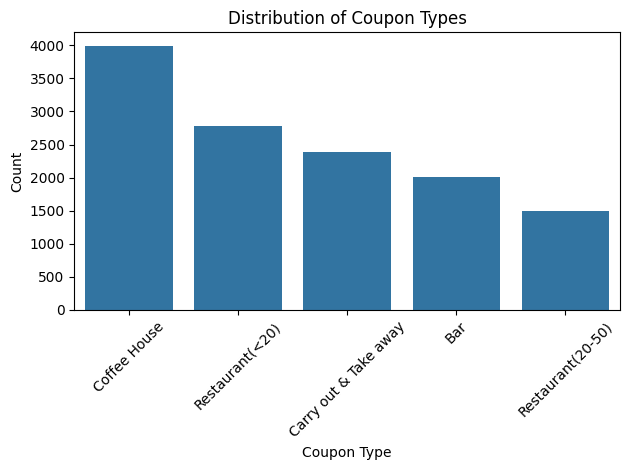

In [76]:
value_counts = data['coupon'].value_counts()
sns.barplot(x=value_counts.index, y=value_counts.values)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 note: here first we counts the occureances of each copons type by ".value_counts" then we plot the labels and counts
this plot shows the disturbutions of the coupons type, and with "proximity to the business is a factor on whether the coupon is delivered" it means there are more coffe houses than the others. 

now, let's add the column "Y" to see how many of these copons were accpted 

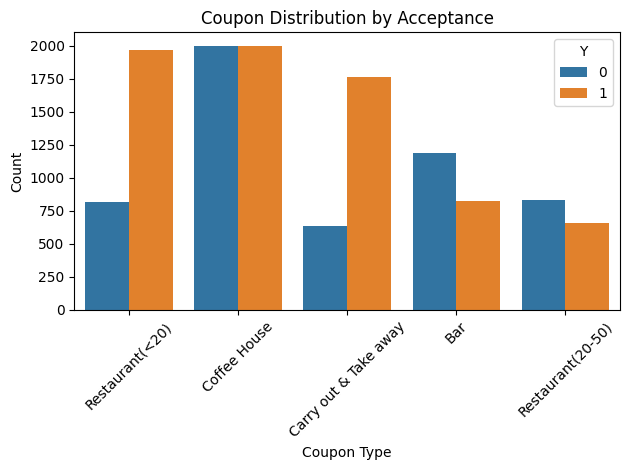

In [77]:
sns.countplot(x='coupon', hue='Y', data=data)
plt.title('Coupon Distribution by Acceptance')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This countplot shows the populaity of typs of coupons, the resturant and take away are the most poular which recived a lot yes than the other two. 

Let's do one more thing to find ou the populaity, in below we will calculates the percentage of the yes and no to coupons: 

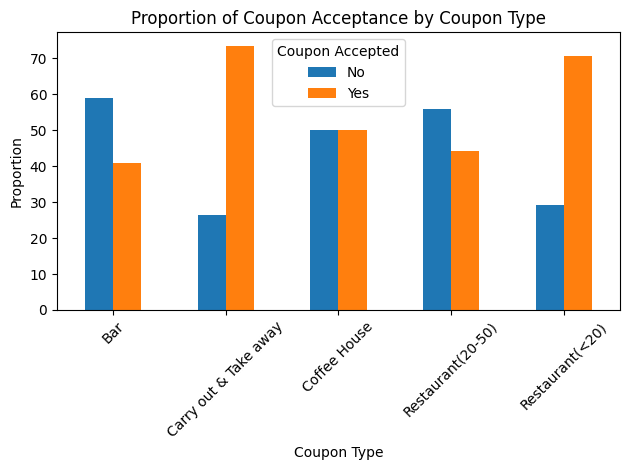

Y                              0          1
coupon                                     
Bar                    58.998513  41.001487
Carry out & Take away  26.452152  73.547848
Coffee House           50.075075  49.924925
Restaurant(20-50)      55.898123  44.101877
Restaurant(<20)        29.289304  70.710696


In [78]:
counts = data.groupby('coupon')['Y'].value_counts(normalize=True).unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages.plot(kind='bar')
plt.title('Proportion of Coupon Acceptance by Coupon Type') 
plt.xlabel('Coupon Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Coupon Accepted', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

print(percentages)

the data again shows that carry out are the most poular type of coupon is "Carry out & Take away" which ~75% accpteance rate.

It is very inteersting that coffee house is 50% accpteance rate. it is a tie!!!! 

6. Use a histogram to visualize the temperature column.

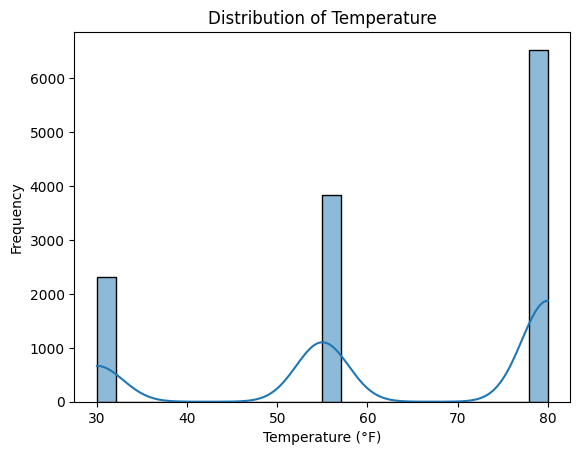

In [79]:
sns.histplot(data=data, x='temperature', kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Frequency')
plt.show()


We already saw in the "Data Description" that we have only 3 temperatures, why do not we have the continuous data? I do not know! maybe for simplicity they just to choose to have cold, warm and hot weather and let's keep going with these wheather.


Let's go back to our populaity study and see what kind of accptance rate we can get with different coupons considering the temperatures:

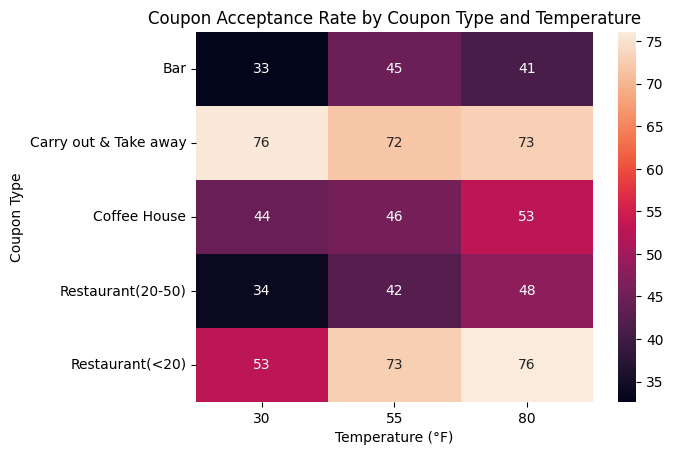

temperature                   30         55         80
coupon                                                
Bar                    32.629108  44.665272  41.102362
Carry out & Take away  75.632490  71.875000  72.983114
Coffee House           44.339623  45.575568  52.977926
Restaurant(20-50)      33.699634  42.391304  48.178613
Restaurant(<20)        52.919708  72.699849  76.063492


In [80]:
acceptance_coupons_by_temp = data.groupby(['coupon', 'temperature'])['Y'].mean()*100
acceptance = acceptance_coupons_by_temp.unstack()

sns.heatmap(acceptance, annot=True)
plt.title('Coupon Acceptance Rate by Coupon Type and Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Coupon Type')
plt.show()

print(acceptance)

Here it shows the accptance perteance of each coupon typs in a different tempreatues. What do we understnad:
1. people will tend to go to resutants (for both of the resturants) when it is hot --> it does not make sense!
2. bar is the same trend
3. coffee house and carry out are almost independent of the tempreatues 

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [81]:
dataframe = data[data["coupon"] == "Bar"]

2. What proportion of bar coupons were accepted?


In [82]:
bar_acceptance = (dataframe['Y'] == 1).sum() / len(dataframe['Y'])
print(f"coupon acceptance rate for bar is: {bar_acceptance:.2%}")

coupon acceptance rate for bar is: 41.00%


We already saw this accpeatnce in cell 20, but it is a nice approch to only focuse on coupon type!

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [83]:
# let's do some intial setps before we start the occurance. First let's see our columns name and how it looks like:

dataframe.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='str')

In [84]:
dataframe["Bar"].unique()

<StringArray>
['never', 'less1', '1~3', 'gt8', nan, '4~8']
Length: 6, dtype: str

In [85]:
# it seems that we have some nan values, before dropping the nan values, let's see how manay yes or no we have for the Y column:

nan_records = dataframe[dataframe['Bar'].isna()]

print(f"Number of NaN records in 'Bar' column: {len(nan_records)}")
print(nan_records['Y'].value_counts())

Number of NaN records in 'Bar' column: 21
Y
0    13
1     8
Name: count, dtype: int64


it seems that we have 8 yes and 13 no for the nan values in bar which we do not have any information for --> we need to drop them. 


In [86]:
dataframe1 = dataframe.dropna(subset=['Bar']) 

# let's group 3 or fewer records in the bar visit per month:
group_high = dataframe1[dataframe1['Bar'].isin(['4~8', 'gt8'])]

group_high_acceptance = (group_high['Y'] == 1).sum() / len(group_high['Y'])*100

print(f"coupon acceptance rate for thoes who visit bar more than 3 times a month: {group_high_acceptance:.2f}%")

coupon acceptance rate for thoes who visit bar more than 3 times a month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [87]:
dataframe1['age'].unique()

<StringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str

In [88]:
target_group = dataframe1[
    (dataframe1['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (dataframe1['age'].isin(['46', '26', '31', '41', '50plus', '36']))]

# other group that is not in the target group:
other_group = dataframe1[~dataframe1.index.isin(target_group.index)]

target_acceptance = (target_group['Y'] == 1).sum() / len(target_group) * 100
other_acceptance = (other_group['Y'] == 1).sum() / len(other_group) * 100

print(f"Bar visits >1/month AND age >25: {target_acceptance:.2f}%")
print(f"All others: {other_acceptance:.2f}%")
print(f"Difference: {target_acceptance - other_acceptance:.2f}%")

Bar visits >1/month AND age >25: 69.52%
All others: 33.44%
Difference: 36.08%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [89]:
target_group = dataframe1[
    (dataframe1['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (dataframe1['passanger'].isin(['Alone','Friend(s)', 'Partner'])) &
    ~(dataframe1['occupation'].str.contains('farming|fishing|forestry', case=False))]

other_group = dataframe1[~dataframe1.index.isin(target_group.index)]

target_acceptance = (target_group['Y'] == 1).sum() / len(target_group) * 100
other_acceptance = (other_group['Y'] == 1).sum() / len(other_group) * 100

print(f"Target group acceptance: {target_acceptance:.2f}%")
print(f"Other group acceptance: {other_acceptance:.2f}%")


Target group acceptance: 71.32%
Other group acceptance: 29.48%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [90]:
target_group1 = dataframe1[
    (dataframe1['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    ~(dataframe1['passanger'].isin(['Kid(s)'])) &
    ~(dataframe1['maritalStatus'].isin(['Widowed']))
]

target_group2 = dataframe1[(dataframe1['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (dataframe1['age'].isin(['below21', '21', '26']))]

target_group3 = dataframe1[(dataframe1['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
                           (dataframe1['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))]

acceptance1 = (target_group1['Y'] == 1).sum() / len(target_group1) * 100
acceptance2 = (target_group2['Y'] == 1).sum() / len(target_group2) * 100
acceptance3 = (target_group3['Y'] == 1).sum() / len(target_group3) * 100

print(f"Acceptance rate for target group 1: {acceptance1:.2f}%")
print(f"Acceptance rate for target group 2: {acceptance2:.2f}%")
print(f"Acceptance rate for target group 3: {acceptance3:.2f}%")

Acceptance rate for target group 1: 71.32%
Acceptance rate for target group 2: 72.17%
Acceptance rate for target group 3: 45.72%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Bar frequency vistis: Drivers who visit bars more than once a month (especially more than 3 times/month) 
   have significantly higher acceptance rates compared to infrequent bar visitors.

Age factor: Younger drivers (particularly under 30) and those under 50 with frequent bar visits show higher 
   acceptance rates.

Passenger influnece: Drivers traveling with friends, partners, or alone are more likely to accept bar coupons 
   compared to those with children, suggesting social context matters.

Marital status: Widowed drivers have lower acceptance rates.

income and dining: he acceptance patterns suggest these are drivers engaged in an active social lifestyle, 
   as evidenced by frequent restaurant visits and bar attendance.

Therefore, the drivers that are socially active, younger, and traveling without children might
    accpet the coupons more than others.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [92]:
coffehouse = data[data["coupon"] == "Coffee House"]

coffee_acceptance = (coffehouse['Y'] == 1).sum() / len(coffehouse['Y'])
print(f"coupon acceptance rate for coffee house is: {coffee_acceptance:.2%}")

coupon acceptance rate for coffee house is: 49.92%


In [93]:
acceptance_coupons_by_time = coffehouse.groupby('time')['Y'].mean().sort_values(ascending=False)*100
print(acceptance_coupons_by_time)

time
10AM    64.071190
2PM     54.785894
7AM     44.578313
10PM    42.424242
6PM     41.262580
Name: Y, dtype: float64


In [94]:
coffehouse['destination'].unique()

<StringArray>
['No Urgent Place', 'Home', 'Work']
Length: 3, dtype: str

it seems that we have more acceptance rate in 10am, now let's see what is thier destionation when they accpet the coffee and see their percentage

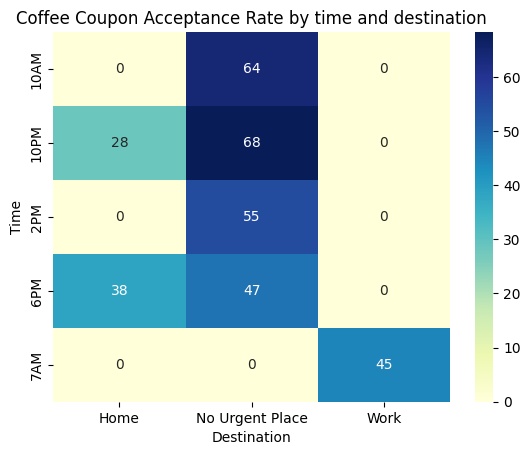

destination       Home  No Urgent Place       Work
time                                              
10AM          0.000000        64.071190   0.000000
10PM         28.497409        68.269231   0.000000
2PM           0.000000        54.785894   0.000000
6PM          38.231293        47.486034   0.000000
7AM           0.000000         0.000000  44.578313


In [101]:
acceptance_coffee_by_temp = coffehouse.groupby(['time', 'destination'])['Y'].mean()*100
acceptance = acceptance_coffee_by_temp.unstack()
acceptance = acceptance.fillna(0)
sns.heatmap(acceptance, annot=True, cmap='YlGnBu')
plt.title('Coffee Coupon Acceptance Rate by time and destination')
plt.xlabel('Destination')
plt.ylabel('Time')
plt.show()

print(acceptance)

it seems that we have some nan values for some conditions which put zero instaed. First I thought there were missing datapoints and then I found there missing combination created with groupby!
or am I missing something?!

Coffee House coupons perform good during the morning rush hour (7 AM) when the destination is 'work', as well as 10 am when the destination is "no urgent place". 2 pm and 6 pm accptance rat eis low. At 10 pm, there are some deriver who accepts coffe hose copoun on the way back home 